In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [4]:
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)

In [5]:
wine = load_wine(as_frame=True)
df = wine.frame.copy()

In [6]:
print("=== 데이터 상위 5행 ===")
display(df.head())

=== 데이터 상위 5행 ===


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [7]:
print("=== 데이터 크기 ===")
print(df.shape)

=== 데이터 크기 ===
(178, 14)


In [8]:
print("=== 컬럼 목록 ===")
print(df.columns.tolist())

=== 컬럼 목록 ===
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']


In [9]:
print("=== 데이터 정보 ===")
df.info()

=== 데이터 정보 ===
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  t

In [10]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [11]:
print("=== 기초 통계량 ===")
display(df.describe().T)

=== 기초 통계량 ===


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [12]:
print("=== target 분포 ===")
print("class names:", wine.target_names)
display(df["target"].value_counts().sort_index())

=== target 분포 ===
class names: ['class_0' 'class_1' 'class_2']


target
0    59
1    71
2    48
Name: count, dtype: int64

In [13]:
X = df.drop(columns="target")
y = df["target"]

print("\n=== X, y 크기 ===")
print("X shape:", X.shape)
print("y shape:", y.shape)


=== X, y 크기 ===
X shape: (178, 13)
y shape: (178,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n=== train / test 크기 ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\n=== train target 분포 ===")
display(y_train.value_counts().sort_index())

print("\n=== test target 분포 ===")
display(y_test.value_counts().sort_index())


=== train / test 크기 ===
X_train: (142, 13)
X_test : (36, 13)
y_train: (142,)
y_test : (36,)

=== train target 분포 ===


target
0    47
1    57
2    38
Name: count, dtype: int64


=== test target 분포 ===


target
0    12
1    14
2    10
Name: count, dtype: int64


=== Logistic Regression 결과 ===
Accuracy: 0.9444444444444444
Macro F1: 0.9407407407407407

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      1.00      0.93        14
           2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



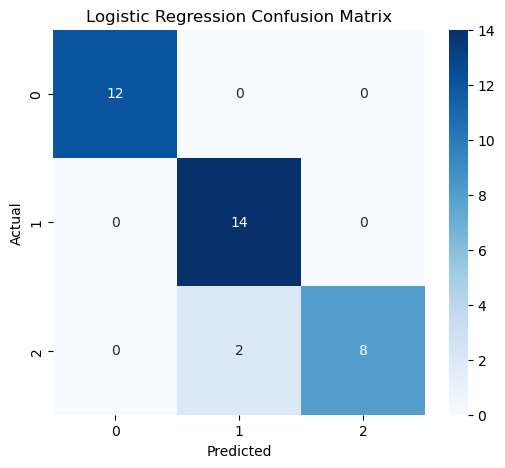

In [15]:
# ---------------------------------------------------------
# 기준 모델 : Logistic Regression
# ---------------------------------------------------------
log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("\n=== Logistic Regression 결과 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Macro F1:", f1_score(y_test, y_pred_log, average="macro"))
print("\n[Classification Report]")
print(classification_report(y_test, y_pred_log))

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Decision Tree 결과 ===
Accuracy: 0.9444444444444444
Macro F1: 0.9457411645054665

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



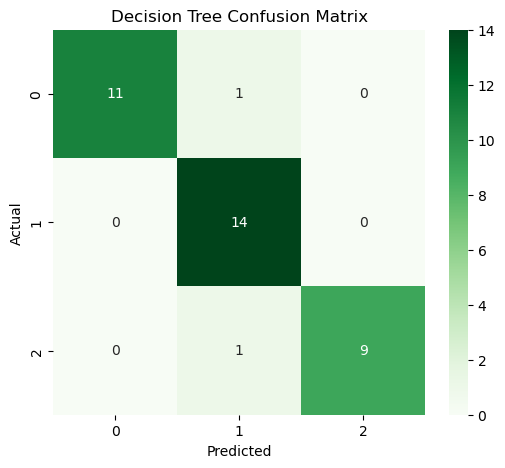

In [16]:
# ---------------------------------------------------------
# 비교 모델 1: Decision Tree
# ---------------------------------------------------------
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("=== Decision Tree 결과 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Macro F1:", f1_score(y_test, y_pred_tree, average="macro"))
print("\n[Classification Report]")
print(classification_report(y_test, y_pred_tree))

cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Random Forest 결과 ===
Accuracy: 1.0
Macro F1: 1.0

[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



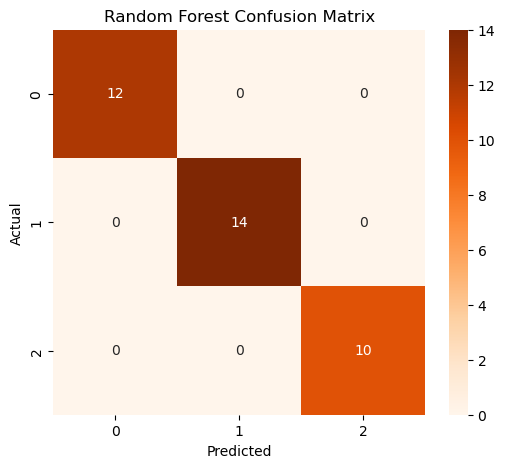

In [17]:
# ---------------------------------------------------------
# 비교 모델 2: Random Forest
# ---------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest 결과 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Macro F1:", f1_score(y_test, y_pred_rf, average="macro"))
print("\n[Classification Report]")
print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# ---------------------------------------------------------
# 모델 성능 비교표
# ---------------------------------------------------------
model_compare = pd.DataFrame({
    "model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "macro_f1": [
        f1_score(y_test, y_pred_log, average="macro"),
        f1_score(y_test, y_pred_tree, average="macro"),
        f1_score(y_test, y_pred_rf, average="macro")
    ]
}).sort_values("macro_f1", ascending=False)

print("=== 모델 비교표 ===")
display(model_compare)

=== 모델 비교표 ===


,model,accuracy,macro_f1
2,Random Forest,1.000000,1.000000
1,Decision Tree,0.944444,0.945741
0,Logistic Regression,0.944444,0.940741


In [19]:
# ---------------------------------------------------------
# Random Forest 중요 변수 확인
# ---------------------------------------------------------
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("=== 중요 변수 표 ===")
display(importance_df)

=== 중요 변수 표 ===


,feature,importance
9,color_intensity,0.187404
6,flavanoids,0.168373
12,proline,0.157024
0,alcohol,0.108171
10,hue,0.094966
11,od280/od315_of_diluted_wines,0.089898
5,total_phenols,0.051274
4,magnesium,0.035210
1,malic_acid,0.030246
8,proanthocyanins,0.028266


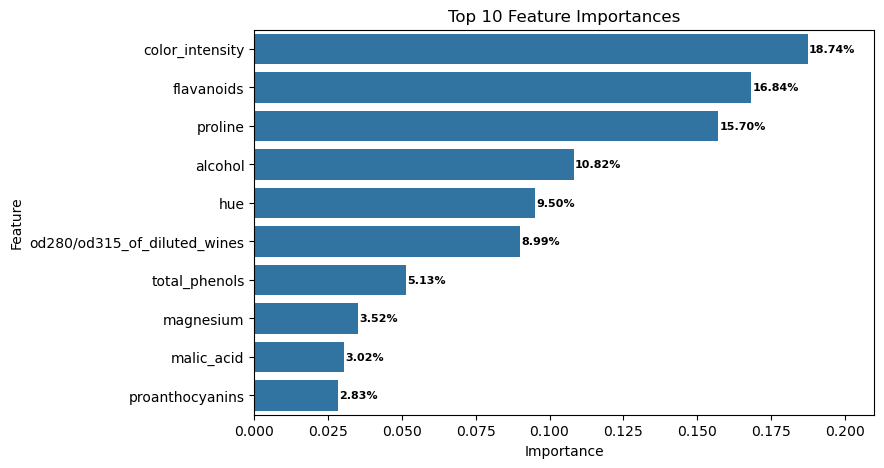

In [20]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=importance_df.head(10), x="importance", y="feature")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}", label_type='edge', padding=1, fontsize=8, color="black", fontweight="bold")
plt.xlim(0, 0.21)
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [21]:
# ---------------------------------------------------------
# 이진 분류용 데이터 만들기
# target == 0 이면 1, 나머지(1,2)는 0
# 불균형 데이터 설명용
# ---------------------------------------------------------
df_binary = df.copy()
df_binary["target_binary"] = (df_binary["target"] == 0).astype(int)

print("=== 이진 target 분포 ===")
display(df_binary["target_binary"].value_counts())

X_bin = df_binary.drop(columns=["target", "target_binary"])
y_bin = df_binary["target_binary"]

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin,
    test_size=0.2,
    random_state=42,
    stratify=y_bin
)

print("=== 이진 분류 train/test target 분포 ===")
print("train:")
display(y_train_bin.value_counts())
print("test:")
display(y_test_bin.value_counts())

=== 이진 target 분포 ===


target_binary
0    119
1     59
Name: count, dtype: int64

=== 이진 분류 train/test target 분포 ===
train:


target_binary
0    95
1    47
Name: count, dtype: int64

test:


target_binary
0    24
1    12
Name: count, dtype: int64

=== Binary Logistic Regression (기본) ===
Accuracy: 0.9722222222222222
F1: 0.96
[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       0.92      1.00      0.96        12

    accuracy                           0.97        36
   macro avg       0.96      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



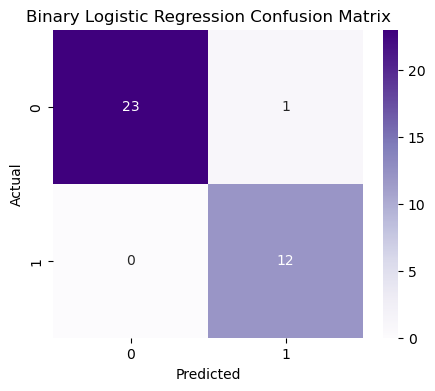

In [22]:
# ---------------------------------------------------------
# 이진 분류 - class_weight 없이
# ---------------------------------------------------------
log_bin = LogisticRegression(max_iter=2000, random_state=42)
log_bin.fit(X_train_bin, y_train_bin)

y_pred_bin = log_bin.predict(X_test_bin)

print("=== Binary Logistic Regression (기본) ===")
print("Accuracy:", accuracy_score(y_test_bin, y_pred_bin))
print("F1:", f1_score(y_test_bin, y_pred_bin))
print("[Classification Report]")
print(classification_report(y_test_bin, y_pred_bin))

cm_bin = confusion_matrix(y_test_bin, y_pred_bin)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Purples")
plt.title("Binary Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Binary Logistic Regression (class_weight='balanced') ===
Accuracy: 0.9722222222222222
F1: 0.96
[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       0.92      1.00      0.96        12

    accuracy                           0.97        36
   macro avg       0.96      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



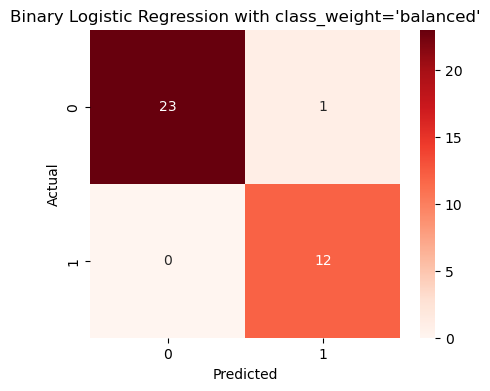

In [23]:
# ---------------------------------------------------------
# 이진 분류 - class_weight='balanced'
# ---------------------------------------------------------
log_bin_balanced = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight="balanced"
)
log_bin_balanced.fit(X_train_bin, y_train_bin)

y_pred_bin_balanced = log_bin_balanced.predict(X_test_bin)

print("=== Binary Logistic Regression (class_weight='balanced') ===")
print("Accuracy:", accuracy_score(y_test_bin, y_pred_bin_balanced))
print("F1:", f1_score(y_test_bin, y_pred_bin_balanced))
print("[Classification Report]")
print(classification_report(y_test_bin, y_pred_bin_balanced))

cm_bin_bal = confusion_matrix(y_test_bin, y_pred_bin_balanced)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_bin_bal, annot=True, fmt="d", cmap="Reds")
plt.title("Binary Logistic Regression with class_weight='balanced'")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Oversampling 전 클래스 개수 ===


target_binary
0    95
1    47
Name: count, dtype: int64

=== Oversampling 후 클래스 개수 ===


target_binary
0    95
1    95
Name: count, dtype: int64

=== Binary Logistic Regression (Oversampling 적용) ===
Accuracy: 0.9722222222222222
F1: 0.96
[Classification Report]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       0.92      1.00      0.96        12

    accuracy                           0.97        36
   macro avg       0.96      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



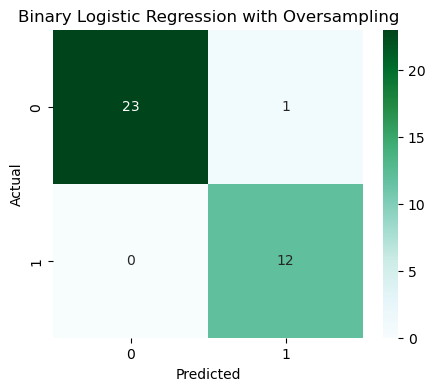

In [24]:
# ---------------------------------------------------------
# 간단한 oversampling 예시
# train 데이터에서만 수행
# ---------------------------------------------------------
train_binary = X_train_bin.copy()
train_binary["target_binary"] = y_train_bin.values

print("=== Oversampling 전 클래스 개수 ===")
display(train_binary["target_binary"].value_counts())

majority = train_binary[train_binary["target_binary"] == 0]
minority = train_binary[train_binary["target_binary"] == 1]

minority_oversampled = minority.sample(
    n=len(majority),
    replace=True,
    random_state=42
)

train_balanced = pd.concat([majority, minority_oversampled], axis=0)

print("=== Oversampling 후 클래스 개수 ===")
display(train_balanced["target_binary"].value_counts())

X_train_over = train_balanced.drop(columns="target_binary")
y_train_over = train_balanced["target_binary"]

log_over = LogisticRegression(max_iter=2000, random_state=42)
log_over.fit(X_train_over, y_train_over)

y_pred_over = log_over.predict(X_test_bin)

print("=== Binary Logistic Regression (Oversampling 적용) ===")
print("Accuracy:", accuracy_score(y_test_bin, y_pred_over))
print("F1:", f1_score(y_test_bin, y_pred_over))
print("[Classification Report]")
print(classification_report(y_test_bin, y_pred_over))

cm_over = confusion_matrix(y_test_bin, y_pred_over)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_over, annot=True, fmt="d", cmap="BuGn")
plt.title("Binary Logistic Regression with Oversampling")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
# ---------------------------------------------------------
# 이진 분류 결과 비교표
# ---------------------------------------------------------
binary_compare = pd.DataFrame({
    "model": [
        "Binary Logistic (basic)",
        "Binary Logistic (class_weight=balanced)",
        "Binary Logistic (oversampling)"
    ],
    "accuracy": [
        accuracy_score(y_test_bin, y_pred_bin),
        accuracy_score(y_test_bin, y_pred_bin_balanced),
        accuracy_score(y_test_bin, y_pred_over)
    ],
    "f1": [
        f1_score(y_test_bin, y_pred_bin),
        f1_score(y_test_bin, y_pred_bin_balanced),
        f1_score(y_test_bin, y_pred_over)
    ]
})

print("=== 이진 분류 결과 비교표 ===")
display(binary_compare)

=== 이진 분류 결과 비교표 ===


,model,accuracy,f1
0,Binary Logistic (basic),0.972222,0.96
1,Binary Logistic (class_weight=balanced),0.972222,0.96
2,Binary Logistic (oversampling),0.972222,0.96


=== GridSearchCV 결과 ===
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9792267014489237
=== Tuned Random Forest 결과 ===
Accuracy: 1.0
Macro F1: 1.0
[Classification Report]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



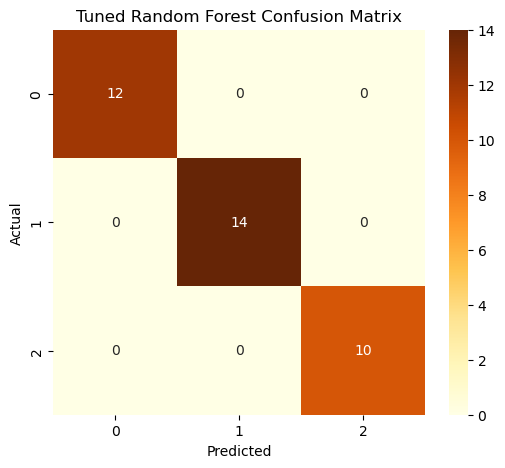

In [26]:
# ---------------------------------------------------------
# Random Forest 하이퍼파라미터 튜닝
# ---------------------------------------------------------
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 3, 5, 10],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("=== GridSearchCV 결과 ===")
print("Best Params:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_rf = grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("=== Tuned Random Forest 결과 ===")
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Macro F1:", f1_score(y_test, y_pred_best_rf, average="macro"))
print("[Classification Report]")
print(classification_report(y_test, y_pred_best_rf))

cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best_rf, annot=True, fmt="d", cmap="YlOrBr")
plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
# ---------------------------------------------------------
# 튜닝 전후 비교
# ---------------------------------------------------------
compare_tuned = pd.DataFrame({
    "model": ["Random Forest", "Tuned Random Forest"],
    "accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_rf)
    ],
    "macro_f1": [
        f1_score(y_test, y_pred_rf, average="macro"),
        f1_score(y_test, y_pred_best_rf, average="macro")
    ]
})

print("=== 튜닝 전후 비교 ===")
display(compare_tuned)

=== 튜닝 전후 비교 ===


,model,accuracy,macro_f1
0,Random Forest,1.0,1.0
1,Tuned Random Forest,1.0,1.0


In [28]:
# ---------------------------------------------------------
# 워크숍용 질문
# ---------------------------------------------------------
print("=== 워크숍 질문 ===")
print("1. 가장 중요한 변수 3개는 무엇인가?")
print("2. 어떤 모델이 가장 좋았는가?")
print("3. confusion matrix에서 가장 많이 헷갈리는 클래스는 무엇인가?")
print("4. class imbalance 대응은 어떤 변화를 만들었는가?")
print("5. 현업에 추천할 모델은 무엇이고, 그 이유는 무엇인가?")

=== 워크숍 질문 ===
1. 가장 중요한 변수 3개는 무엇인가?
2. 어떤 모델이 가장 좋았는가?
3. confusion matrix에서 가장 많이 헷갈리는 클래스는 무엇인가?
4. class imbalance 대응은 어떤 변화를 만들었는가?
5. 현업에 추천할 모델은 무엇이고, 그 이유는 무엇인가?


In [29]:
# ---------------------------------------------------------
# 4주차 연결 질문
# ---------------------------------------------------------
print("=== 다음 시간 생각해볼 질문 ===")
print("- 범주가 아니라 숫자를 예측하면 무엇이 달라질까?")
print("- 분류 지표와 회귀 지표는 어떻게 다를까?")
print("- feature importance 해석은 회귀에서도 가능할까?")

=== 다음 시간 생각해볼 질문 ===
- 범주가 아니라 숫자를 예측하면 무엇이 달라질까?
- 분류 지표와 회귀 지표는 어떻게 다를까?
- feature importance 해석은 회귀에서도 가능할까?


In [30]:
# ---------------------------------------------------------
# 최종 한 줄 정리
# ---------------------------------------------------------
print("=== 오늘 실습 정리 ===")
print("1. 분류 문제를 정의했다.")
print("2. baseline 모델과 비교 모델을 만들었다.")
print("3. confusion matrix와 classification report를 해석했다.")
print("4. class imbalance 대응 방법을 실습했다.")
print("5. 하이퍼파라미터 튜닝까지 수행했다.")

=== 오늘 실습 정리 ===
1. 분류 문제를 정의했다.
2. baseline 모델과 비교 모델을 만들었다.
3. confusion matrix와 classification report를 해석했다.
4. class imbalance 대응 방법을 실습했다.
5. 하이퍼파라미터 튜닝까지 수행했다.


In [31]:
# end